In [2]:
import pandas as pd

df_Lung_Cancer = pd.read_csv('Lung Cancer.csv')
print(df_Lung_Cancer)

df_Lung_Cancer_Prediction_Dataset = pd.read_csv('Lung Cancer Prediction Dataset.csv')
print(df_Lung_Cancer_Prediction_Dataset)

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

    GENDER  AGE  SMOKING  ...  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER
0        M   69        1  ...                      2           2          YES
1        M   74        2  ...                      2           2          YES
2        F   59        1  ...                      1           2           NO
3        M   63        2  ...                      2           2           NO
4        F   63        1  ...                      1           1           NO
..     ...  ...      ...  ...                    ...         ...          ...
304      F   56        1  ...                      2           1          YES
305      M   70        2  ...                      1           2          YES
306      M   58        2  ...                      1           2          YES
307      M   67        2  ...                      1           2          YES
308      M   62        1  ...                      2           1          YES

[309 rows x 16 columns]
      AGE  GENDER  ...  STRESS_IMMUNE  

              precision    recall  f1-score   support

           0       0.67      0.60      0.63        10
           1       0.92      0.94      0.93        52

    accuracy                           0.89        62
   macro avg       0.80      0.77      0.78        62
weighted avg       0.88      0.89      0.88        62


Accuracy: 0.8871
F1-Score: 0.9333
Precision: 0.9245
Recall: 0.9423
[[ 6  4]
 [ 3 49]]


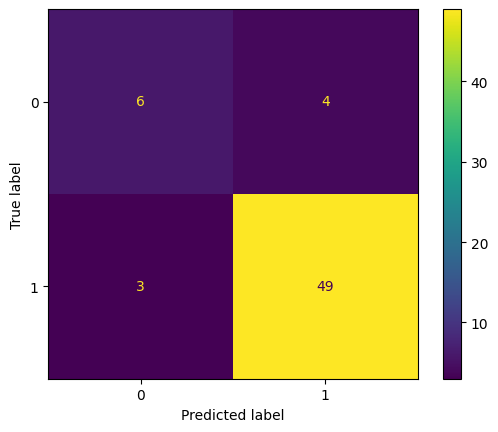


Decision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.8902
Mean Precision: 0.9304
Mean Recall   : 0.9444
Mean F1-score : 0.9369

Feature Importance Ranking
                  Feature    Importance
0                ALLERGY   2.585597e-01
1                     AGE  1.741287e-01
2   SWALLOWING DIFFICULTY  1.232183e-01
3           PEER_PRESSURE  8.911700e-02
4                 ANXIETY  6.521498e-02
5       ALCOHOL CONSUMING  5.238701e-02
6                 SMOKING  4.051639e-02
7                FATIGUE   3.558585e-02
8                COUGHING  3.503602e-02
9                  GENDER  3.207988e-02
10         YELLOW_FINGERS  2.416295e-02
11               WHEEZING  2.406570e-02
12    SHORTNESS OF BREATH  2.346519e-02
13        CHRONIC DISEASE  2.246235e-02
14             CHEST PAIN  4.221499e-17


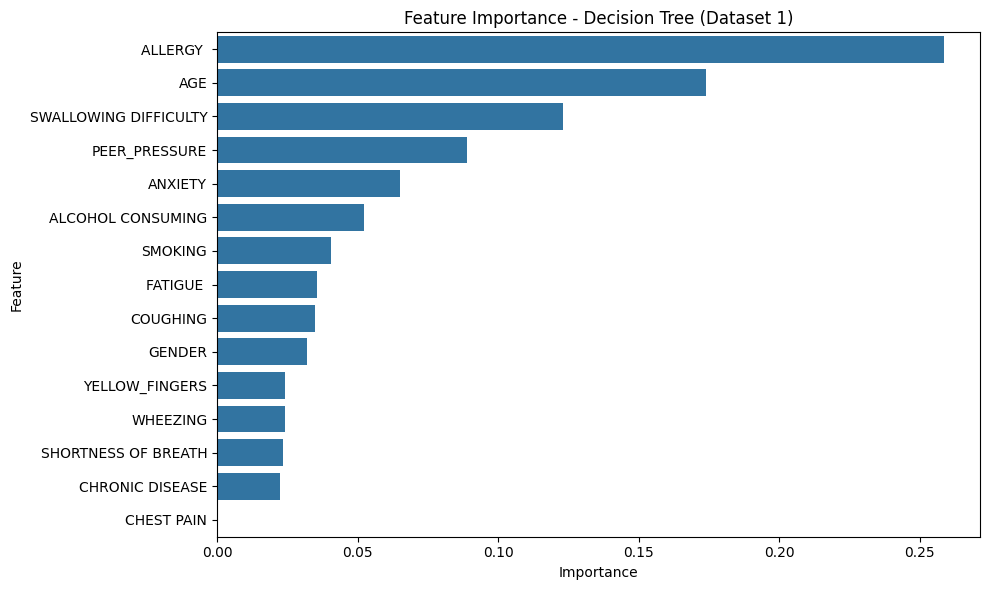


Individual Feature Results (5-Fold CV)
              Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                FATIGUE              1  0.676097   0.908446  0.700000   
1                     AGE             1  0.647488   0.904488  0.666667   
2     SHORTNESS OF BREATH             1  0.624643   0.890742  0.651852   
3                COUGHING             1  0.640666   0.946563  0.625926   
4                ALLERGY              1  0.650714   0.970422  0.618519   
5       ALCOHOL CONSUMING             1  0.637758   0.958112  0.611111   
6          YELLOW_FINGERS             1  0.611740   0.926095  0.603704   
7                WHEEZING             1  0.624326   0.949043  0.603704   
8              CHEST PAIN             1  0.605182   0.930917  0.592593   
9                 SMOKING             1  0.566526   0.887825  0.574074   
10          PEER_PRESSURE             1  0.563458   0.938938  0.537037   
11                 GENDER             1  0.540561   0.897891  0.537037  

In [8]:
#Dataset 1 - Lung Cancer
import sklearn
from sklearn import tree #https://scikit-learn.org/stable/modules/tree.html
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder #https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
df_Lung_Cancer['GENDER'] = LabelEncoder().fit_transform(df_Lung_Cancer['GENDER'])
df_Lung_Cancer['LUNG_CANCER'] = LabelEncoder().fit_transform(df_Lung_Cancer['LUNG_CANCER'])
X1 = df_Lung_Cancer.drop(columns=['LUNG_CANCER'])
y1 = df_Lung_Cancer['LUNG_CANCER']

#BASELINE MODEL
model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X1,y1,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report,accuracy_score, precision_score, recall_score, f1_score

print(classification_report(y_test, model.predict(X_test)))


print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

#BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X1,
    y1,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 1 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

#FEATURE IMPORTANCE
dt_model_full = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_full.fit(X1, y1)

feature_importance_df = pd.DataFrame({
    "Feature": X1.columns,
    "Importance": dt_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree (Dataset 1)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X1[[feature]]

    single_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X1[selected_features]

    topk_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y1,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       593
           1       0.79      0.81      0.80       407

    accuracy                           0.84      1000
   macro avg       0.83      0.83      0.83      1000
weighted avg       0.84      0.84      0.84      1000


Accuracy: 0.8380
F1-Score: 0.8034
Precision: 0.7938
Recall: 0.8133
[[507  86]
 [ 76 331]]


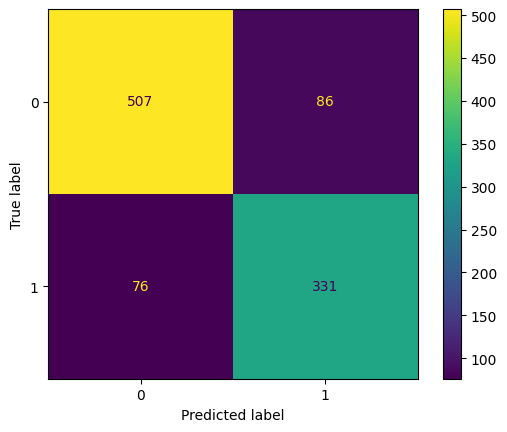

In [ ]:
#Dataset 2
df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'] = LabelEncoder().fit_transform(df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE'])
X1 = df_Lung_Cancer_Prediction_Dataset.drop(columns=['PULMONARY_DISEASE'])
y1 = df_Lung_Cancer_Prediction_Dataset['PULMONARY_DISEASE']

model = tree.DecisionTreeClassifier(class_weight='balanced') #https://scikit-learn.org/stable/glossary.html#term-class_weight


X_train, X_test, y_train, y_test = train_test_split(X1,y1,test_size=0.2)

model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

              precision    recall  f1-score   support

           0       0.45      0.44      0.45      3144
           1       0.75      0.76      0.75      6856

    accuracy                           0.66     10000
   macro avg       0.60      0.60      0.60     10000
weighted avg       0.65      0.66      0.66     10000


Accuracy: 0.6569
F1-Score: 0.7515
Precision: 0.7463
Recall: 0.7569
[[1380 1764]
 [1667 5189]]


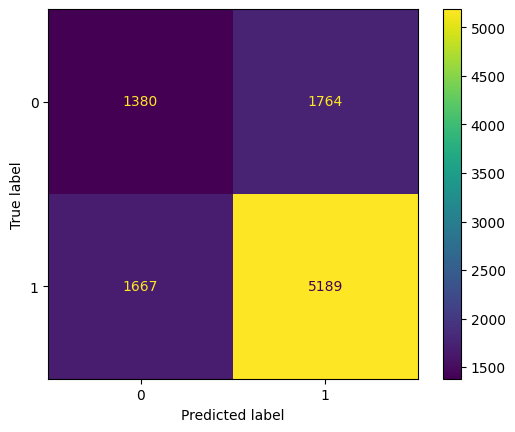

In [ ]:
#Dataset 3
for col in df_Lung_Cancer_Risk_Dataset.columns:
  df_Lung_Cancer_Risk_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Risk_Dataset[col])

x1 = df_Lung_Cancer_Risk_Dataset.drop(columns=['lung_cancer'])
y1 = df_Lung_Cancer_Risk_Dataset['lung_cancer']

model = tree.DecisionTreeClassifier(class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(x1,y1,test_size=0.2)
model.fit(X_train,y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()